# DBSCAN. Практическая работа

## Цель практической работы

Научиться строить модели кластеризации с помощью метода DBSCAN.

## Что входит в работу


- Загрузите данные и проведите разведочный анализ.
- Предположите оптимальное количество кластеров.
- Постройте модель кластеризации DBSCAN.
- Определите оптимальное количество и структуру кластеров.
- Интерпретируйте полученные результаты.

## Что оценивается 

1. Выполнены все задания.
2. Сделаны выводы по результатам разведочного анализа данных.
3. Объяснены выбранные гиперпараметры модели кластеризации.
4. Сделаны выводы о количестве и структуре кластеров.
5. Сделаны выводы по результатам кластеризации.

# Задача

Имеется некоторый набор данных `gt_2015.csv` о производительности и других параметрах ветряных электростанций:
* AT — температура окружающей среды.
* PT — давление окружающей среды.
* AH — влажность окружающей среды. 
* AFDP — перепад давления на воздушном фильтре. 
* GTEP — давление на выходе из газовой турбины. 
* TIT — температура на входе в турбину.
* TAT — температура на выходе из турбины. 
* TEY — энергоотдача турбины.
* CDP — давление нагнетания компрессора.
* CO — выбросы угарного газа. 
* NOX — выбросы оксидов азота.

Решите задачу кластеризации электростанций для дальнейшего совместного управления схожими электростанциями.

# Задание 1

Загрузите датасет и выполните разведочный анализ данных. Сделайте выводы о найденных закономерностях, особенностях и других свойствах данных, которые вы обнаружите.

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import StandardScaler

import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.manifold import TSNE
from sklearn.cluster import DBSCAN
from sklearn.model_selection import GridSearchCV


In [3]:
df = pd.read_csv('gt_2015.csv')
df.head()

,AT,AP,AH,AFDP,GTEP,TIT,TAT,TEY,CDP,CO,NOX
0,1.95320,1020.1,84.985,2.5304,20.116,1048.7,544.92,116.27,10.799,7.4491,113.250
1,1.21910,1020.1,87.523,2.3937,18.584,1045.5,548.50,109.18,10.347,6.4684,112.020
2,0.94915,1022.2,78.335,2.7789,22.264,1068.8,549.95,125.88,11.256,3.6335,88.147
3,1.00750,1021.7,76.942,2.8170,23.358,1075.2,549.63,132.21,11.702,3.1972,87.078
4,1.28580,1021.6,76.732,2.8377,23.483,1076.2,549.68,133.58,11.737,2.3833,82.515


In [4]:
df.describe()

,AT,AP,AH,AFDP,GTEP,TIT,TAT,TEY,CDP,CO,NOX
count,7384.000000,7384.00000,7384.000000,7384.000000,7384.000000,7384.000000,7384.000000,7384.000000,7384.000000,7384.000000,7384.000000
mean,17.225259,1014.50911,68.647464,3.598909,26.130149,1078.974689,546.642484,133.993380,12.097025,3.129986,59.890509
std,8.095783,6.89543,13.541116,0.610226,4.473737,19.762449,5.489066,16.179208,1.136601,2.234962,11.132464
min,-6.234800,989.40000,24.085000,2.368800,17.698000,1016.000000,516.040000,100.020000,9.870800,0.212800,25.905000
25%,11.073250,1009.67500,59.447250,3.117300,23.147000,1070.500000,544.747500,126.255000,11.465750,1.808175,52.399000
50%,17.456500,1014.00000,70.952000,3.538500,25.331000,1080.300000,549.720000,131.600000,11.933000,2.533400,56.838500
75%,23.684750,1018.30000,79.653750,4.194825,30.018250,1099.900000,550.030000,147.160000,13.148000,3.702550,65.093250
max,37.103000,1036.60000,96.666000,5.239500,40.716000,1100.400000,550.590000,179.500000,15.159000,41.097000,119.680000


Histogram for AT


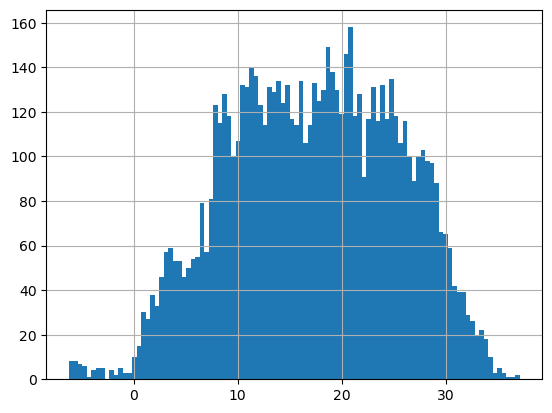

Histogram for AP


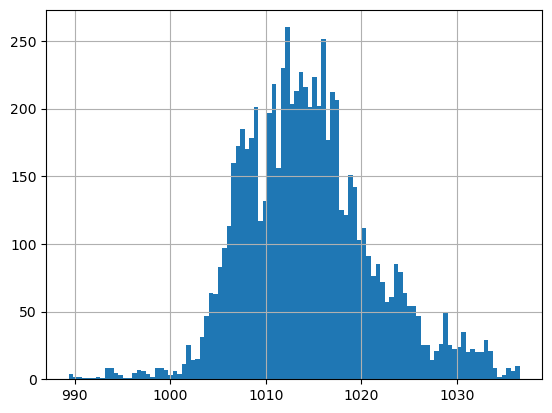

Histogram for AH


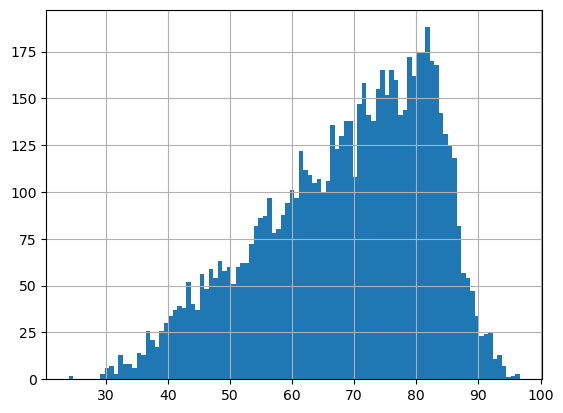

Histogram for AFDP


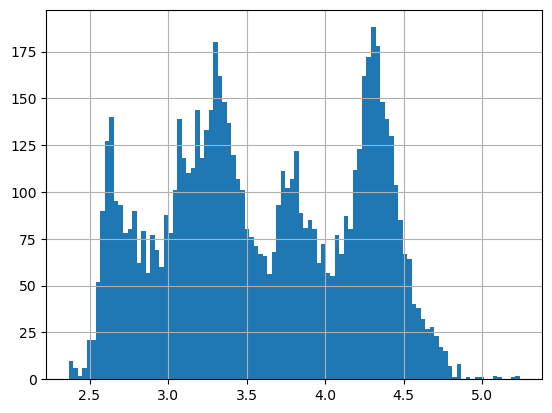

Histogram for GTEP


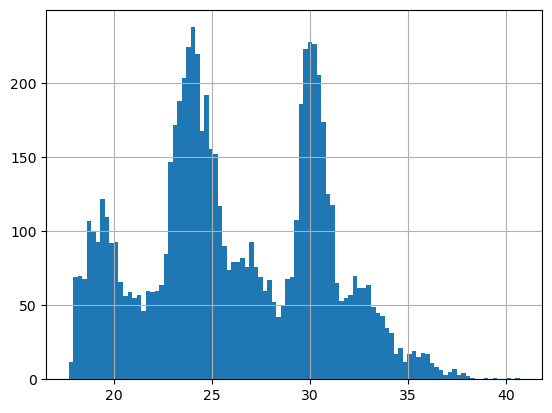

Histogram for TIT


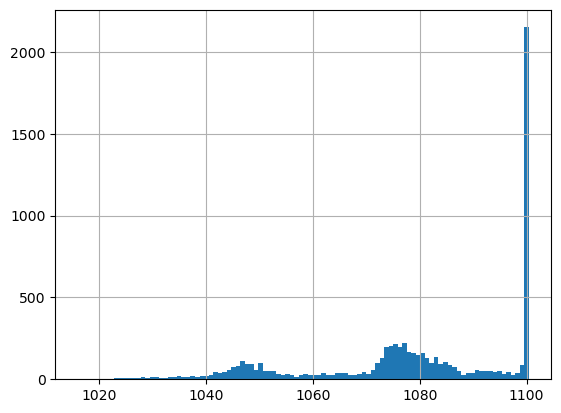

Histogram for TAT


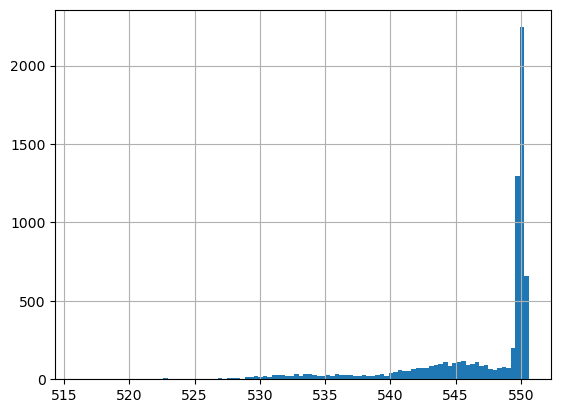

Histogram for TEY


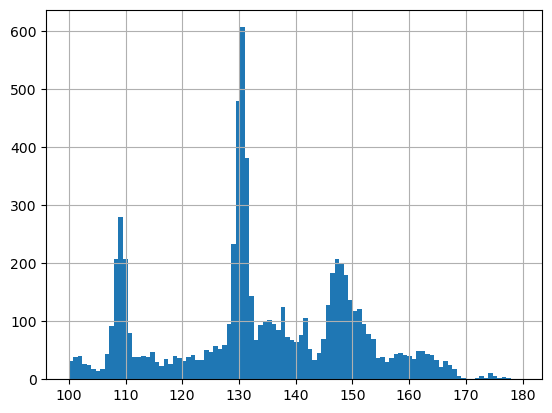

Histogram for CDP


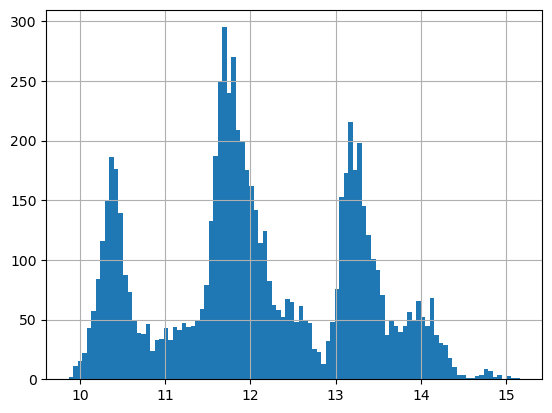

Histogram for CO


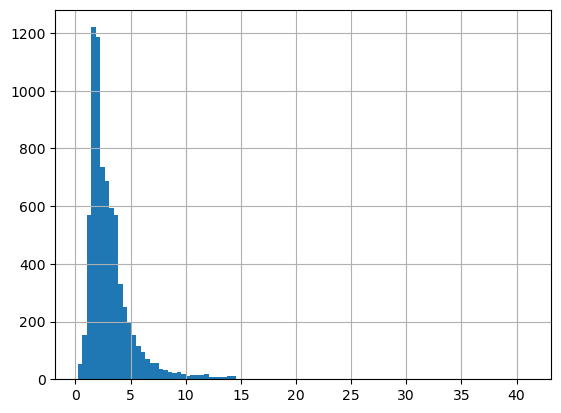

Histogram for NOX


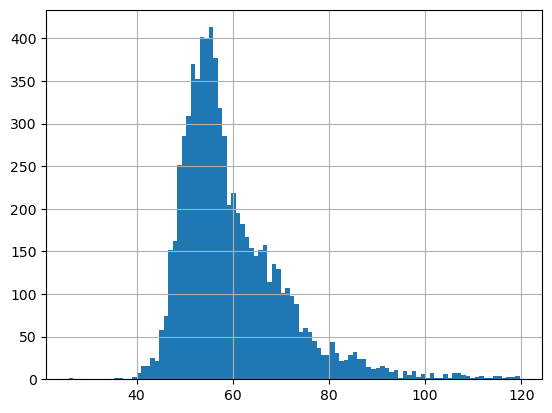

In [7]:
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns

for col in numerical_features:
  print(f'Histogram for {col}')
  df[col].hist(bins=100)
  plt.show()

boxplot for AT


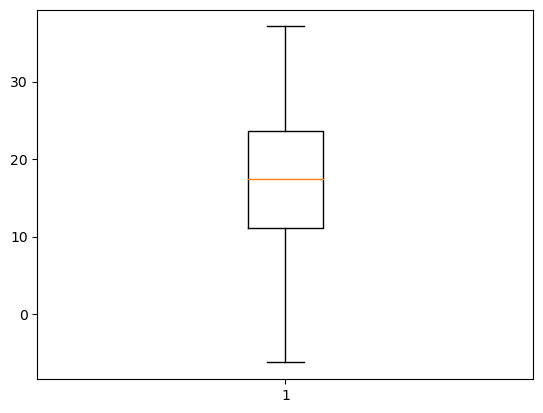

boxplot for AP


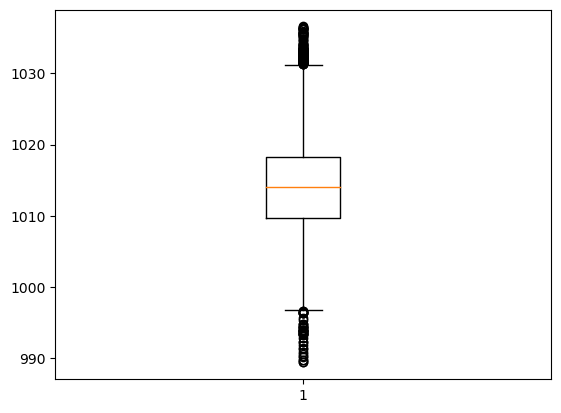

boxplot for AH


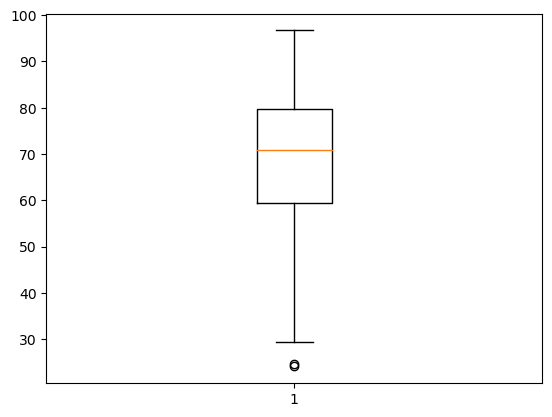

boxplot for AFDP


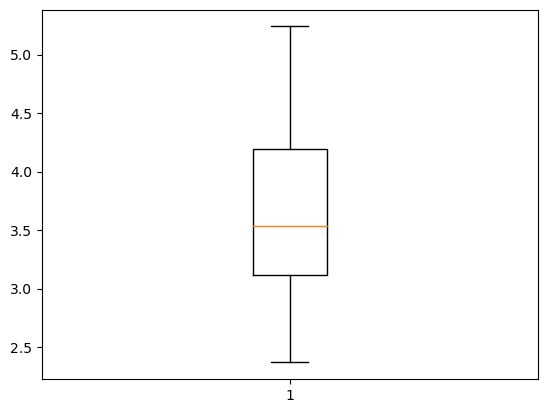

boxplot for GTEP


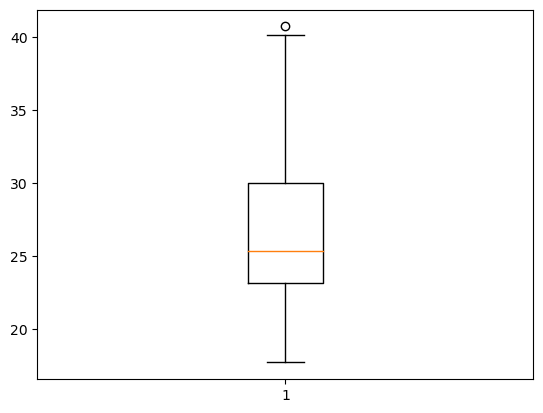

boxplot for TIT


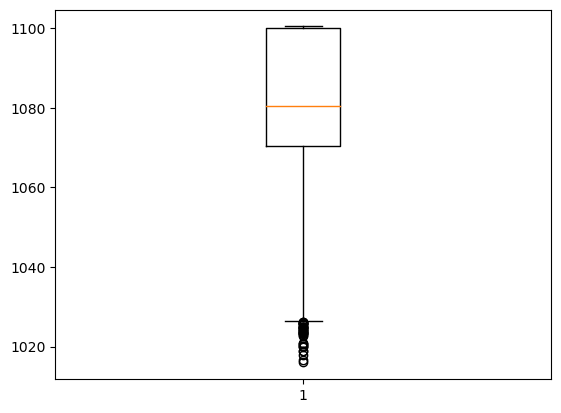

boxplot for TAT


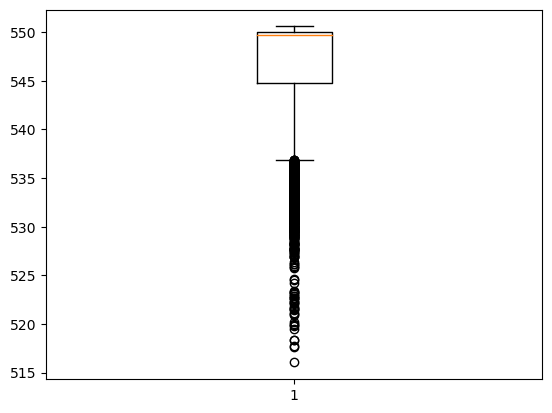

boxplot for TEY


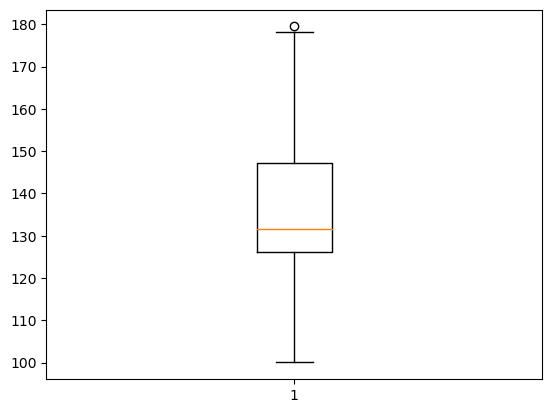

boxplot for CDP


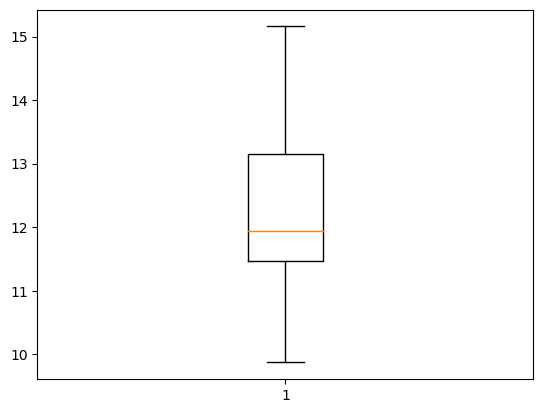

boxplot for CO


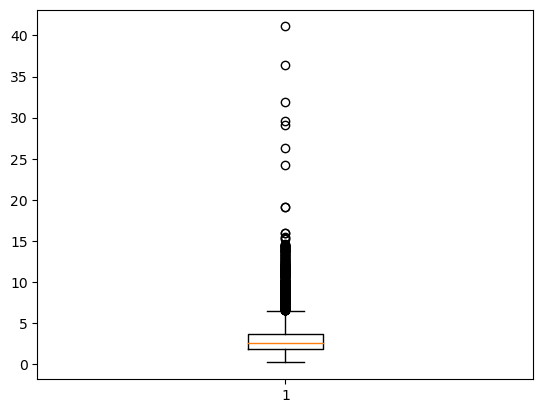

boxplot for NOX


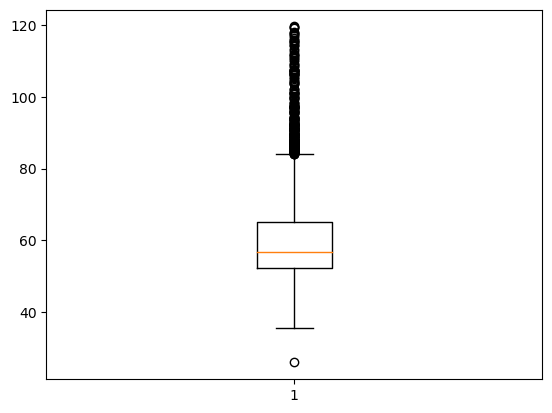

In [12]:
for col in numerical_features:    
    print(f'boxplot for {col}')
    plt.boxplot(df[col])
    plt.show()

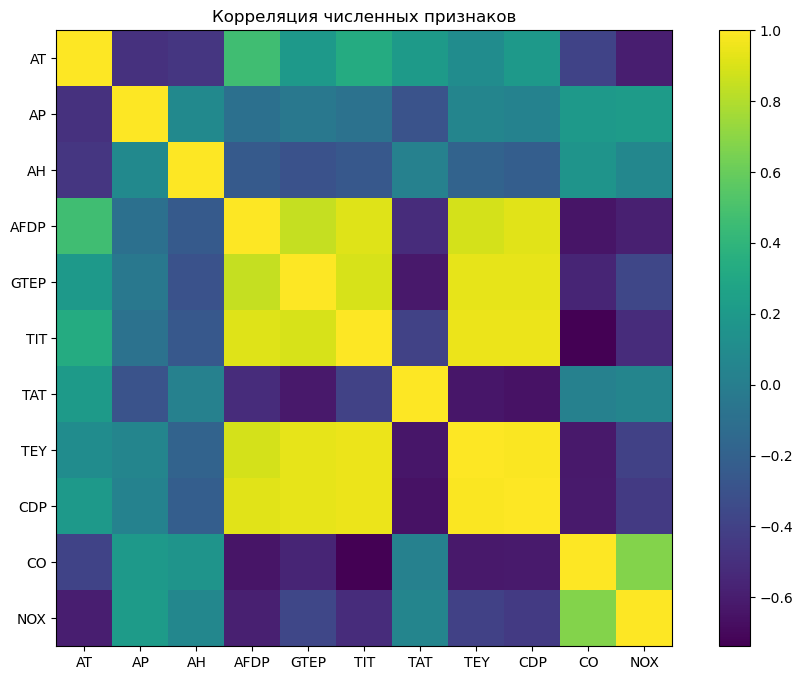

In [9]:
plt.figure(figsize=(12, 8))

columns = df.corr().columns.tolist()
plt.imshow(df.corr())

plt.title("Корреляция численных признаков")
plt.xticks(range(0, len(columns)), columns)
plt.yticks(range(0, len(columns)), columns)
plt.colorbar()
plt.show()

# Задание 2

Предположите по результатам разведочного анализа данных, какие группы электростанций существуют, чем они отличаются, каково их количество.

# Задание 3

Постройте модель кластеризации DBSCAN. Подберите оптимальные гиперпараметры, руководствуясь как результатами сеточного поиска, так и результатами анализа данных в предыдущих заданиях.

In [14]:
scaler = StandardScaler()
X_train = scaler.fit_transform(df)
X_train = pd.DataFrame(X_train, columns=df.columns)
X_train

,AT,AP,AH,AFDP,GTEP,TIT,TAT,TEY,CDP,CO,NOX
0,-1.886549,0.810866,1.206595,-1.751125,-1.344414,-1.532034,-0.313824,-1.095516,-1.142101,1.932653,4.793468
1,-1.977232,0.810866,1.394037,-1.975155,-1.686881,-1.693968,0.338426,-1.533762,-1.539805,1.493824,4.682972
2,-2.010579,1.115436,0.715465,-1.343871,-0.864246,-0.514884,0.602605,-0.501504,-0.739998,0.225305,2.538378
3,-2.003371,1.042919,0.612586,-1.281431,-0.619691,-0.191016,0.544304,-0.110234,-0.347573,0.030076,2.442346
4,-1.968993,1.028416,0.597077,-1.247506,-0.591749,-0.140412,0.553413,-0.025552,-0.316777,-0.334116,2.032436
...,...,...,...,...,...,...,...,...,...,...,...
7379,-1.679810,2.029146,1.813307,-0.709309,-1.574439,-2.124106,-0.920526,-1.539944,-1.483493,3.518425,2.630458
7380,-1.613030,2.043650,1.875049,-0.666371,-1.590311,-2.093743,-0.794813,-1.557869,-1.542445,3.585992,2.601441
7381,-1.450638,2.029146,1.962418,-0.468889,-1.625854,-2.073501,-0.576181,-1.618445,-1.438619,3.706807,3.257046
7382,-1.401017,2.058153,1.887161,0.629631,-0.573865,-0.104988,0.631756,-0.159684,-0.286861,0.082072,0.435467


  File "C:\ProgramData\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 199, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\ProgramData\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\ProgramData\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\ProgramData\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


<Axes: >

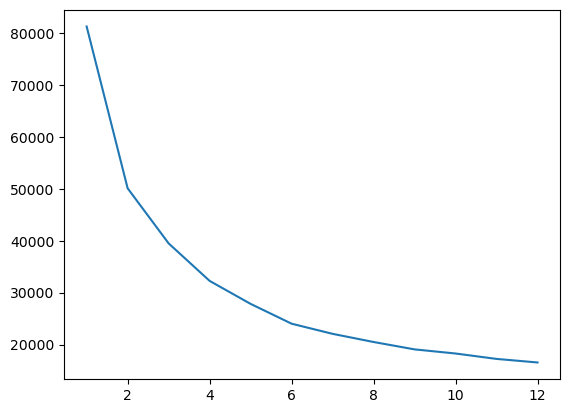

In [15]:
X_train_s = X_train.values

# Определяем количество кластеров
n_clusters = list(range(1, 13))

metrics = []

for k in n_clusters:
  km = KMeans(n_clusters=k, random_state=63,).fit(X_train)
  metrics.append(km.inertia_)


sns.lineplot(x=n_clusters, y=metrics)

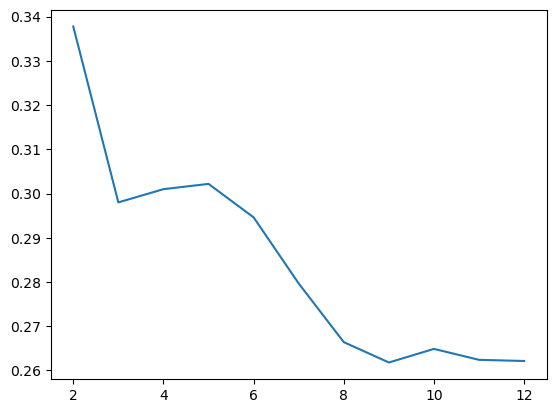

In [16]:
n_clusters = list(range(2, 13))
metrics = []
for k in n_clusters:
  km = KMeans(n_clusters=k).fit(X_train)
  score = silhouette_score(X_train_s, km.labels_)
  metrics.append(score)
sns.lineplot(x=n_clusters, y=metrics);


In [64]:
silhouette = -1
best_eps = -1
best_min_smpl = -1
for min_sample in range(5, 8):
    for eps in np.arange(3.5, 4.3, 0.1):
        model = DBSCAN(eps=eps, min_samples=min_sample)
        model.fit(X_train_s)
        df['labels'] = model.labels_
        if silhouette_score(X_train_s, df['labels']) > silhouette:
            silhouette = silhouette_score(X_train_s, df['labels'])
            best_eps = eps
            best_min_smpl = min_sample
print(f'Best silhouette={silhouette}, Best eps={best_eps}, Best min_samples={best_min_smpl}')

Best silhouette=0.6715035300574999, Best eps=3.8000000000000003, Best min_samples=5


In [84]:
model = DBSCAN(eps=3.8, min_samples=5)
model.fit(X_train_s)
df['labels'] = model.labels_
silhouette_score(X_train_s, df['labels'])

0.6715035300574999

In [85]:
df['labels'].value_counts()

 0    7376
-1       8
Name: labels, dtype: int64

In [86]:
features = ['AT', 'AP', 'AH', 'AFDP', 'GTEP', 'TIT', 'TAT', 'TEY', 'CDP', 'CO', 'NOX']

df_g = df.groupby('labels').agg({x: ['mean', 'std'] for x in features}).T

In [87]:
functions = ['mean', 'std']

stat = np.array([[df[feature].apply(f) for f in functions] for feature in features]).flatten()

df_g_rel = df_g.copy()
df_g_rel['Global'] = stat


In [88]:
cluster_labels = [0, -1]

for label in cluster_labels:
  df_g_rel[label] = 100 * df_g_rel[label] / df_g_rel['Global'] - 100

<Axes: xlabel='labels', ylabel='None-None'>

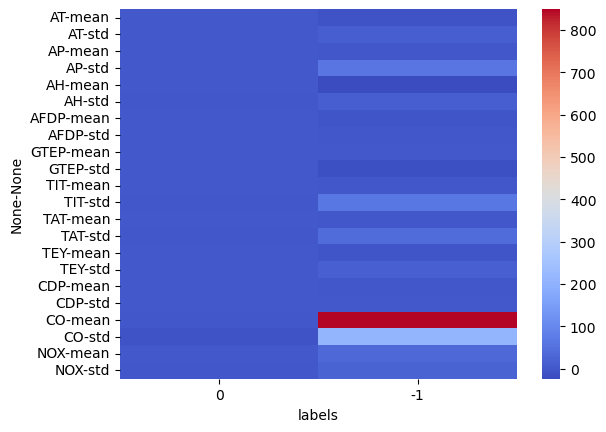

In [89]:
sns.heatmap(df_g_rel[cluster_labels], cmap='coolwarm')

# Задание 4

Интерпретируйте результаты кластеризации: объясните, чем схожи электростанции в каждом кластере и чем аномальные электростанции отличаются от остальных. 

**Как отправить работу на проверку**

Скачайте файл с работой в материалах, откройте его через Jupyter Notebook и выполните задания. Сохраните изменения при помощи опции Save and Checkpoint на вкладке меню File или кнопки Save and Checkpoint на панели инструментов. Отправьте через форму ниже итоговый файл Jupyter Notebook (в формате .ipynb) или ссылку на него.
